# Phase 2 multi-key null-variance pilot

## TL;DR

This executed notebook validates and analyses the frozen 500-prompt, paired-length,
ten-key null pilot for canonical KGW SelfHash and SynthID-Text. Its purpose is to
decide the calibration policy and the next research gate; it does **not** freeze a
publication threshold.

In [1]:
from pathlib import Path
import csv
import json
import math

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path.cwd()
analysis_path = ROOT / "results/phase2-variance-pilot/analysis.json"
scores_path = ROOT / "results/phase2-variance-pilot/scores.csv"
replication_path = ROOT / "results/phase2-variance-replication/analysis.json"
analysis = json.loads(analysis_path.read_text(encoding="utf-8"))
replication = json.loads(replication_path.read_text(encoding="utf-8"))
with scores_path.open(encoding="utf-8", newline="") as handle:
    scores = list(csv.DictReader(handle))
for row in scores:
    row["length"] = int(row["length"])
    row["value"] = float(row["value"])
    row["eligible_positions"] = int(row["eligible_positions"])

assert analysis["validation"]["passed"]
assert replication["validation"]["passed"]
assert len(scores) == 30_000
print(f"Validated {len(scores):,} score rows across {len(analysis['cell_summaries'])} cells.")

Validated 30,000 score rows across 60 cells.


In [2]:
effects = {(x["scheme"], x["length"]): x for x in analysis["key_effects"]}
kgw512 = effects[("kgw", 512)]
syn512 = effects[("synthid", 512)]
pooled_1 = {
    (x["scheme"], x["length"]): x
    for x in analysis["pooled_threshold_key_distortion"]
    if x["target_fpr"] == 0.01
}
theory512 = [x for x in analysis["theoretical_kgw_tails"] if x["length"] == 512]
theory_rates = [x["one_sided_1_percent"]["empirical_rate"] for x in theory512]

display(Markdown(f'''
**Decision-grade result.** Across ten keys at 512 tokens, KGW key means span
**{kgw512['minimum_key_mean']:.3f} to {kgw512['maximum_key_mean']:.3f} z**. The
nominal one-sided 1% standard-normal cutoff yields key-specific empirical rates of
**{min(theory_rates):.1%} to {max(theory_rates):.1%}**. Even one pooled empirical
1% cutoff yields **{pooled_1[('kgw', 512)]['minimum_key_rate']:.1%} to
{pooled_1[('kgw', 512)]['maximum_key_rate']:.1%}** across keys.

SynthID is materially more key-stable: its 512-token key means span
**{syn512['minimum_key_mean']:.5f} to {syn512['maximum_key_mean']:.5f}**, and its
pooled empirical 1% cutoff yields **{pooled_1[('synthid', 512)]['minimum_key_rate']:.1%}
to {pooled_1[('synthid', 512)]['maximum_key_rate']:.1%}** across keys.

Therefore: **reject a shared/theoretical KGW threshold; retain key-conditional KGW
calibration.** A pooled SynthID calibration remains supportable for the next pilot,
with independent-model stability now demonstrated but held-out confirmation still required.
'''))


**Decision-grade result.** Across ten keys at 512 tokens, KGW key means span
**-1.978 to 2.273 z**. The
nominal one-sided 1% standard-normal cutoff yields key-specific empirical rates of
**0.2% to 47.0%**. Even one pooled empirical
1% cutoff yields **0.0% to
7.2%** across keys.

SynthID is materially more key-stable: its 512-token key means span
**0.49862 to 0.50067**, and its
pooled empirical 1% cutoff yields **0.2%
to 1.8%** across keys.

Therefore: **reject a shared/theoretical KGW threshold; retain key-conditional KGW
calibration.** A pooled SynthID calibration remains supportable for the next pilot,
with independent-model stability now demonstrated but held-out confirmation still required.


## Context & Methods

The frozen design generated one 512-token unwatermarked continuation for each of
500 balanced Dolly prompts, then derived paired 128-, 256-, and 512-token prefixes.
Every prefix was scored under ten deterministic KGW keys and ten deterministic
SynthID key vectors. Pairing holds prompt and generated text fixed while key and
length vary, so observed key differences cannot be attributed to different prompt
samples.

The runner checkpointed atomically, preserved input fingerprints, and performed
native-versus-compact full-trace audits on the first prompt at every length.

## Data

In [3]:
checks = analysis["validation"]["checks"]
display(Markdown("### Validation checks\n" + "\n".join(
    f"- {'PASS' if passed else 'FAIL'} — `{name}`" for name, passed in checks.items()
)))

print("Rows by scheme and length:")
for scheme in ("kgw", "synthid"):
    print(scheme, {length: sum(r["scheme"] == scheme and r["length"] == length for r in scores)
                   for length in (128, 256, 512)})

### Validation checks
- PASS — `status_complete`
- PASS — `record_count`
- PASS — `balanced_categories`
- PASS — `generated_lengths`
- PASS — `prefix_shape`
- PASS — `expected_score_rows`
- PASS — `unique_score_cells`
- PASS — `finite_positive_scores`
- PASS — `compact_formula_reconstruction`
- PASS — `native_trace_audits`

Rows by scheme and length:
kgw {128: 5000, 256: 5000, 512: 5000}
synthid {128: 5000, 256: 5000, 512: 5000}


## Results

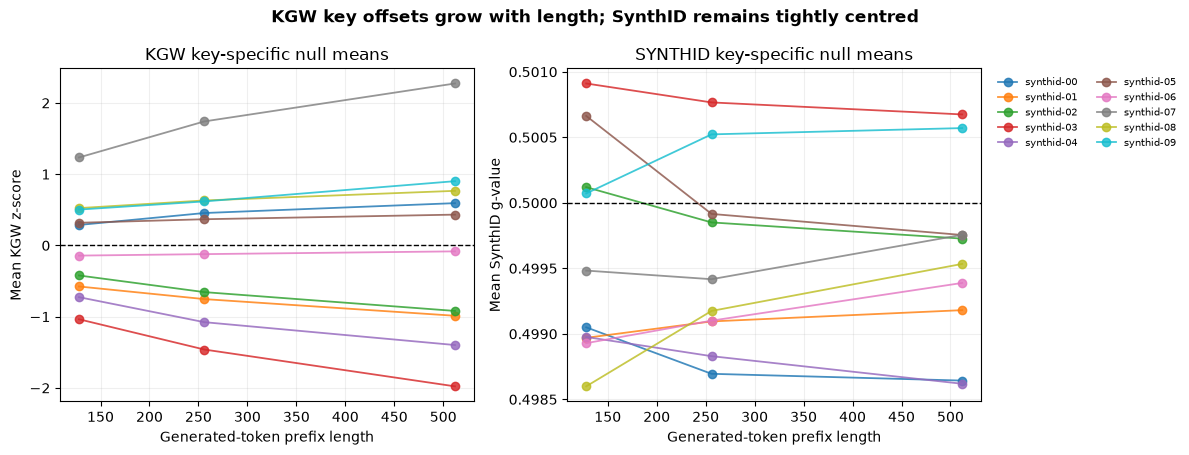

In [4]:
cells = analysis["cell_summaries"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, scheme, reference, ylabel in [
    (axes[0], "kgw", 0.0, "Mean KGW z-score"),
    (axes[1], "synthid", 0.5, "Mean SynthID g-value"),
]:
    key_ids = sorted({x["key_id"] for x in cells if x["scheme"] == scheme})
    for key_id in key_ids:
        items = sorted(
            (x for x in cells if x["scheme"] == scheme and x["key_id"] == key_id),
            key=lambda x: x["length"],
        )
        ax.plot([x["length"] for x in items], [x["mean"] for x in items],
                marker="o", linewidth=1.3, alpha=0.82, label=key_id)
    ax.axhline(reference, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{scheme.upper()} key-specific null means")
    ax.set_xlabel("Generated-token prefix length")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.2)
axes[1].legend(ncol=2, fontsize=7, frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("KGW key offsets grow with length; SynthID remains tightly centred", fontweight="bold")
fig.tight_layout()
plt.show()

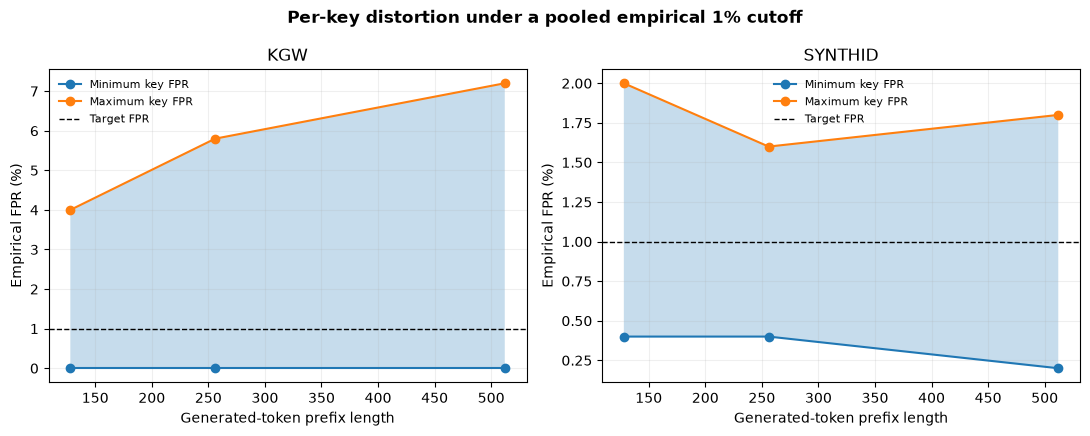

In [5]:
distortion = [x for x in analysis["pooled_threshold_key_distortion"] if x["target_fpr"] == 0.01]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharex=True)
for ax, scheme in zip(axes, ("kgw", "synthid")):
    items = sorted((x for x in distortion if x["scheme"] == scheme), key=lambda x: x["length"])
    lengths = [x["length"] for x in items]
    lows = [100*x["minimum_key_rate"] for x in items]
    highs = [100*x["maximum_key_rate"] for x in items]
    ax.fill_between(lengths, lows, highs, alpha=0.25)
    ax.plot(lengths, lows, marker="o", label="Minimum key FPR")
    ax.plot(lengths, highs, marker="o", label="Maximum key FPR")
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1, label="Target FPR")
    ax.set_title(scheme.upper())
    ax.set_xlabel("Generated-token prefix length")
    ax.set_ylabel("Empirical FPR (%)")
    ax.grid(alpha=0.2)
    ax.legend(frameon=False, fontsize=8)
fig.suptitle("Per-key distortion under a pooled empirical 1% cutoff", fontweight="bold")
fig.tight_layout()
plt.show()

In [6]:
print("Key-effect summary")
print("scheme  length  mean across keys  between-key SD  key range  keys >3 SE")
for x in analysis["key_effects"]:
    print(f"{x['scheme']:7s} {x['length']:6d} {x['mean_across_key_means']:16.6f} "
          f"{x['between_key_standard_deviation']:15.6f} {x['key_mean_range']:10.6f} "
          f"{x['keys_beyond_three_standard_errors']:10d}")

Key-effect summary
scheme  length  mean across keys  between-key SD  key range  keys >3 SE
kgw        128        -0.003769        0.696458   2.270629          9
kgw        256        -0.025846        0.968980   3.201330          9
kgw        512        -0.040067        1.281652   4.250914          9
synthid    128         0.499577        0.000809   0.002311          0
synthid    256         0.499537        0.000704   0.002071          0
synthid    512         0.499585        0.000688   0.002056          2


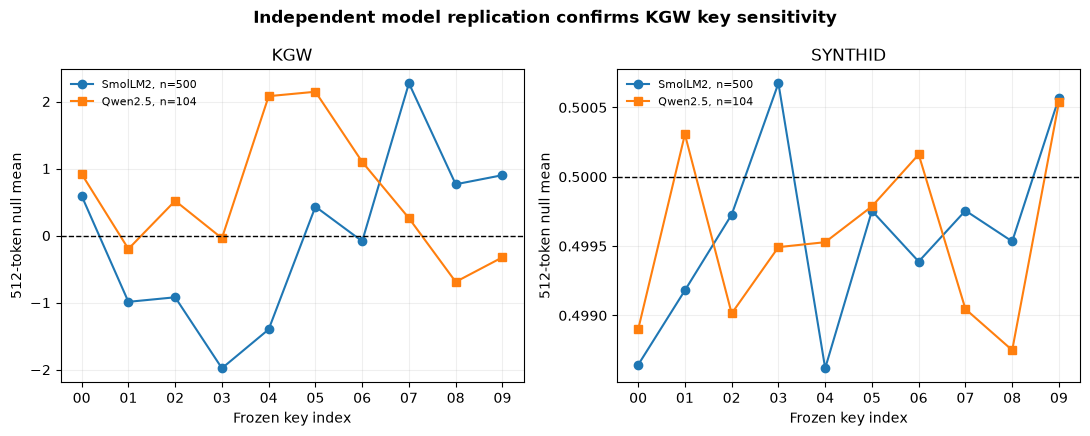

The Qwen replication passed all validation checks. At 512 tokens,
KGW key means span **-0.690 to
2.146 z**, while SynthID spans
**0.49875 to
0.50054**.

In [7]:
primary_512 = [x for x in analysis["cell_summaries"] if x["length"] == 512]
replication_512 = [x for x in replication["cell_summaries"] if x["length"] == 512]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, scheme, reference in zip(axes, ("kgw", "synthid"), (0.0, 0.5)):
    keys = sorted(x["key_id"] for x in primary_512 if x["scheme"] == scheme)
    primary_means = {x["key_id"]: x["mean"] for x in primary_512 if x["scheme"] == scheme}
    replication_means = {x["key_id"]: x["mean"] for x in replication_512 if x["scheme"] == scheme}
    positions = range(len(keys))
    ax.plot(positions, [primary_means[k] for k in keys], marker="o", label="SmolLM2, n=500")
    ax.plot(positions, [replication_means[k] for k in keys], marker="s", label="Qwen2.5, n=104")
    ax.axhline(reference, color="black", linestyle="--", linewidth=1)
    ax.set_xticks(list(positions), [k.split("-")[-1] for k in keys])
    ax.set_xlabel("Frozen key index")
    ax.set_ylabel("512-token null mean")
    ax.set_title(scheme.upper())
    ax.grid(alpha=0.2)
    ax.legend(frameon=False, fontsize=8)
fig.suptitle("Independent model replication confirms KGW key sensitivity", fontweight="bold")
fig.tight_layout()
plt.show()

rep_effects = {(x["scheme"], x["length"]): x for x in replication["key_effects"]}
display(Markdown(f'''The Qwen replication passed all validation checks. At 512 tokens,
KGW key means span **{rep_effects[("kgw", 512)]["minimum_key_mean"]:.3f} to
{rep_effects[("kgw", 512)]["maximum_key_mean"]:.3f} z**, while SynthID spans
**{rep_effects[("synthid", 512)]["minimum_key_mean"]:.5f} to
{rep_effects[("synthid", 512)]["maximum_key_mean"]:.5f}**.'''))

## Precision and power

In [8]:
plan = analysis["precision_plan"]
display(Markdown("### False-positive precision\n" + "\n".join(
    f"- At **{x['target_fpr']:.1%} FPR**, use **{x['recommended_rounded_sample_size']:,}** "
    f"independent null samples per confirmatory calibration cell for an approximate "
    f"30% relative 95% half-width (expected exceedances: {x['expected_exceedances']:.0f})."
    for x in plan["false_positive_precision"]
)))
print("Mean-shift sensitivity (80% power, two-sided alpha 0.05):")
for x in plan["mean_effect_power_scenarios"]:
    print(f"  standardized effect {x['standardized_mean_effect']:.1f}: "
          f"n={x['samples_for_80_percent_power_two_sided_5_percent_alpha']}")
print("Caveat:", plan["positive_outcome_caveat"])

### False-positive precision
- At **1.0% FPR**, use **5,000** independent null samples per confirmatory calibration cell for an approximate 30% relative 95% half-width (expected exceedances: 50).
- At **0.1% FPR**, use **43,000** independent null samples per confirmatory calibration cell for an approximate 30% relative 95% half-width (expected exceedances: 43).

Mean-shift sensitivity (80% power, two-sided alpha 0.05):
  standardized effect 0.1: n=785
  standardized effect 0.2: n=197
  standardized effect 0.3: n=88
  standardized effect 0.5: n=32
Caveat: Attack-condition power remains provisional until repeated watermarked positive and attack variances are measured.


## Takeaways

1. **KGW:** use detector-key × model × length-bin empirical calibration. Neither
   the standard-normal threshold nor one pooled multi-key cutoff controls FPR.
2. **SynthID:** pooled calibration across the tested keys is sufficiently stable to
   proceed to independent replication, but the 500-sample pilot is not a publication
   threshold set.
3. **Confirmatory null:** prioritise disjoint 5,000-sample calibration and
   5,000-sample confirmation sets per primary 1% FPR cell. Do not make 0.1% FPR
   primary unless the budget supports
   roughly 43,000 nulls per cell.
4. **Independent replication:** the balanced Qwen2.5 replication in a clean,
   lockfile-derived environment confirms KGW key sensitivity and SynthID stability.
5. **Gate decision:** **no-go for the attack corpus** until held-out,
   key-conditional KGW calibration reaches the planned 1% FPR precision and its
   thresholds are tested on independent confirmation data.
6. **Attack power:** collect repeated watermarked positive and attacked-positive
   variance before finalising attack sample sizes; null-only power is insufficient.

The ten scores per text are paired, not 5,000 independent texts. Pooled cutoffs here
are development diagnostics; confirmatory uncertainty must be estimated from
independent held-out null examples.